# K-VECINOS MÁS CERCANOS (KNN)

## 1. Importación de librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sklearn.datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix

**Resultado:** Las librerías necesarias para generar datos, entrenar KNN, dividir muestras y visualizar resultados quedaron cargadas.

## 2. Generación del conjunto de datos

In [2]:
N = 1000
noisy_data = sklearn.datasets.make_moons(
    n_samples=N,
    noise=.23,
    random_state=23
)

X, Y = noisy_data

print(X.shape)
print(Y.shape)

(1000, 2)
(1000,)


**Resultado:** Se generaron 1,000 observaciones con dos variables predictoras y una etiqueta binaria.

## 3. Visualización de las clases

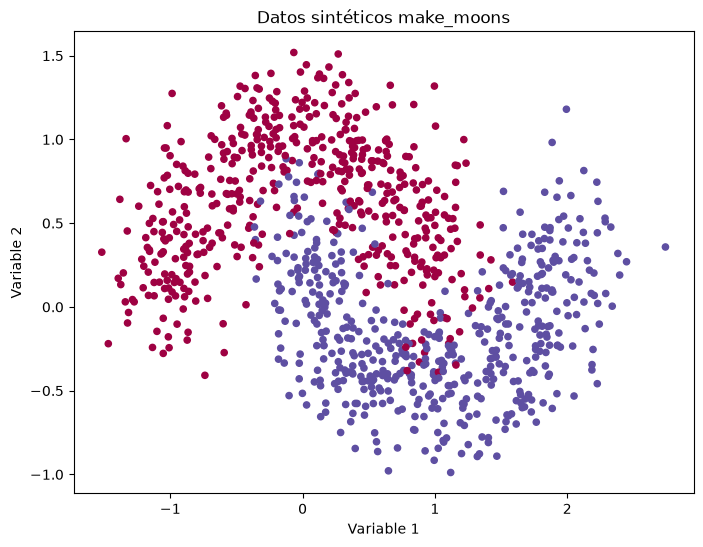

In [3]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=Y, s=20, cmap=plt.cm.Spectral)
plt.xlabel("Variable 1")
plt.ylabel("Variable 2")
plt.title("Datos sintéticos make_moons")
plt.show()

**Resultado:** La gráfica muestra dos clases con forma de medias lunas y cierto traslape causado por el ruido.

## 4. División en entrenamiento y prueba

In [4]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    train_size=.60,
    random_state=23,
    stratify=Y
)

print(X_train.shape)
print(Y_train.shape)
print(X_test.shape)
print(Y_test.shape)

(600, 2)
(600,)
(400, 2)
(400,)


**Resultado:** La división produjo 600 observaciones de entrenamiento y 400 de prueba, manteniendo la proporción de las clases.

## 5. Modelo KNN con tres vecinos

In [5]:
modelo_kNN = KNeighborsClassifier(n_neighbors=3)

modelo_kNN.fit(X_train, Y_train)

print("Exactitud en entrenamiento:", modelo_kNN.score(X_train, Y_train))
print("Exactitud en prueba:", modelo_kNN.score(X_test, Y_test))

Exactitud en entrenamiento: 0.97
Exactitud en prueba: 0.925


**Resultado:** El modelo obtiene 97.00 % de exactitud en entrenamiento y 92.50 % en prueba. La diferencia muestra un sobreajuste moderado con tres vecinos.

## 6. Comparación del número de vecinos

In [6]:
for k in range(1, 16):
  modelo_kNN = KNeighborsClassifier(n_neighbors=k)
  modelo_kNN.fit(X_train, Y_train)

  trs = modelo_kNN.score(X_train, Y_train)
  tes = modelo_kNN.score(X_test, Y_test)

  print('k=%d\tTrain: %.4f\tTest: %.4f' % (k, trs, tes))

k=1	Train: 1.0000	Test: 0.9225
k=2	Train: 0.9733	Test: 0.9050
k=3	Train: 0.9700	Test: 0.9250
k=4	Train: 0.9667	Test: 0.9250
k=5	Train: 0.9650	Test: 0.9350
k=6	Train: 0.9633	Test: 0.9400
k=7	Train: 0.9650	Test: 0.9375
k=8	Train: 0.9667	Test: 0.9325
k=9	Train: 0.9633	Test: 0.9275
k=10	Train: 0.9633	Test: 0.9325
k=11	Train: 0.9667	Test: 0.9300
k=12	Train: 0.9683	Test: 0.9350
k=13	Train: 0.9683	Test: 0.9325
k=14	Train: 0.9633	Test: 0.9325
k=15	Train: 0.9633	Test: 0.9300


**Resultado:** El mejor resultado de prueba fue 94.00 % con k=6. Con k=1 el entrenamiento llega a 100 %, señal de mayor riesgo de sobreajuste.

## 7. Importación de Grid Search

In [7]:
from sklearn.model_selection import GridSearchCV

**Resultado:** GridSearchCV quedó disponible para evaluar sistemáticamente todas las combinaciones indicadas.

## 8. Búsqueda exhaustiva de hiperparámetros

In [8]:
dicc_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

kNN = KNeighborsClassifier()

modelo_kNN = GridSearchCV(
    kNN,
    param_grid=dicc_grid,
    cv=3
)

modelo_kNN.fit(X_train, Y_train)

print(
    "Los mejores parámetros son %s con un score de %0.4f"
    % (modelo_kNN.best_params_, modelo_kNN.best_score_)
)

Los mejores parámetros son {'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'} con un score de 0.9633


**Resultado:** Grid Search seleccionó k=7, distancia euclidiana y pesos uniformes, con una exactitud media de validación cruzada de 96.33 %.

## 9. Evaluación del mejor modelo de Grid Search

In [9]:
kNN_grid = modelo_kNN.best_estimator_

print("Exactitud en entrenamiento:", kNN_grid.score(X_train, Y_train))
print("Exactitud en prueba:", kNN_grid.score(X_test, Y_test))

Exactitud en entrenamiento: 0.965
Exactitud en prueba: 0.9375


**Resultado:** El mejor estimador de Grid Search obtuvo 96.50 % en entrenamiento y 93.75 % en prueba, con una diferencia pequeña entre ambos conjuntos.

## 10. Importación de Randomized Search

In [10]:
from sklearn.model_selection import RandomizedSearchCV

**Resultado:** RandomizedSearchCV quedó disponible para probar una muestra aleatoria del espacio de hiperparámetros.

## 11. Búsqueda aleatoria de hiperparámetros

In [11]:
dicc_grid = {
    'n_neighbors': [1, 3, 5, 7, 9, 11, 13, 15, 17],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
    'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute']
}

kNN = KNeighborsClassifier()

modelo_kNN = RandomizedSearchCV(
    kNN,
    param_distributions=dicc_grid,
    cv=5,
    n_iter=20,
    random_state=23
)

modelo_kNN.fit(X_train, Y_train)

print(
    "Los mejores parámetros son %s\ncon un score de %0.4f"
    % (modelo_kNN.best_params_, modelo_kNN.best_score_)
)

Los mejores parámetros son {'weights': 'uniform', 'n_neighbors': 11, 'metric': 'manhattan', 'algorithm': 'ball_tree'}
con un score de 0.9650


**Resultado:** Randomized Search seleccionó k=11, distancia Manhattan, pesos uniformes y algoritmo ball_tree, con una exactitud media de 96.50 %.

## 12. Evaluación del mejor modelo aleatorio

In [12]:
kNN_random = modelo_kNN.best_estimator_

print("Exactitud en entrenamiento:", kNN_random.score(X_train, Y_train))
print("Exactitud en prueba:", kNN_random.score(X_test, Y_test))

Exactitud en entrenamiento: 0.9633333333333334
Exactitud en prueba: 0.9375


**Resultado:** El mejor modelo aleatorio obtuvo 96.33 % en entrenamiento y 93.75 % en prueba, igualando la exactitud de prueba del modelo encontrado por Grid Search.